# Réplica del 1.er puesto: *trans-fitting* con máquinas de vectores soporte (Youn *et al.*, 2019)

**Anexo de código del TFM.** Pronóstico de crecimiento de grietas por fatiga (PHM Data Challenge 2019).
Carlos J. Bravo I.

Réplica independiente de *Fatigue Crack Length Estimation and Prediction using Trans-fitting with
Support Vector Regression* (Youn, Kim, Lee, Cho y Youn; *PHM Society Conference*, 2019), la entrada
ganadora del certamen, con una penalización oficial total de 7.36.

Es el único de los tres métodos premiados que renuncia por completo a la mecánica de la fractura.
Sus autores declaran que no pueden emplearla por faltarles la geometría del espécimen y las
propiedades del material:

> *the shape of the initial crack, specimen geometry, and material properties*

En su lugar la sustituyen por un procedimiento empírico de traslado de curvas que denominan
*trans-fitting*.

## Contenido

| Apartado | Contenido |
|---|---|
| 1 | Metodología del artículo |
| 2 | Tratamiento de señal |
| 3 | Preparación del conjunto de datos |
| 4 | El modelo: regresión de vectores soporte y *trans-fitting* |
| 5 | Ajuste |
| 6 | Resultados |
| 7 | Comparación con el artículo y con la clasificación del certamen |
| 8 | Conclusiones |
| 9 | Glosario |

> **Referencias de comparación.** El artículo reporta un único total, 7.36, y no desglosa su
> penalización por espécimen. Sus tablas sí publican las predicciones ciclo a ciclo, de modo que el
> desglose puede reconstruirse: normalizando por la grieta final de cada espécimen resulta
> **T7 = 3.41 y T8 = 3.94**, cuya suma reproduce su total. El apartado 7 lo calcula y documenta la
> errata que hay que corregir para que cuadre.

In [1]:
import sys, time, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from data_loader import (SpecimenData, load_all, TRAINING_SPECIMENS,
                         VALIDATION_SPECIMENS, SAMPLING_FREQUENCY_HZ)
from signal_processing import (FeatureExtractor, bandpass_filter, detect_onset,
                               FEATURE_WINDOW_SAMPLES)
from crack_estimator import (build_feature_table, CrackLengthEstimator,
                             grid_search, PAPER_BEST_PARAMS)
from trans_fitting import goodness_of_fit_table, select_candidate, sequential_trans_fit
from variable_loading import (fit_paris_law_exponent, equivalent_stress_ratio,
                              variable_loading_exponent)
from pipeline import (train_estimator, estimate_specimen, predict_specimen,
                      fit_reference_curve, PAPER_TABLES, TRANSLOCATION_LAMBDA)
import scoring

DATA_ROOT = Path("../PHMDC2019_Data")
pd.set_option("display.width", 200)
COLOR = {"T1": "#2a78d6", "T2": "#008300", "T3": "#e87ba4", "T4": "#eda100",
         "T5": "#8a8987", "T6": "#1baf7a", "T7": "#eb6834", "T8": "#4a3aa7"}
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "lines.linewidth": 1.6})

todos = load_all(DATA_ROOT, TRAINING_SPECIMENS + VALIDATION_SPECIMENS)
print("Especímenes cargados:", list(todos))
print(f"Hiperparámetros publicados del SVR: {PAPER_BEST_PARAMS}")

MARCA_DE_AGUA = "Carlos J. Bravo (2026)"

def marca_de_agua(fig, texto=MARCA_DE_AGUA):
    fig.text(0.995, 0.004, texto, fontsize=8, color="0.45", alpha=0.38,
             ha="right", va="bottom", fontweight="bold")
    return fig

from src.referencias_phm import tabla_comparativa, desviacion


Especímenes cargados: ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8']
Hiperparámetros publicados del SVR: {'kernel': 'rbf', 'C': 100.0, 'gamma': 1.0}


## 1. Metodología del artículo

El método consta de dos etapas encadenadas, de las cuales la segunda constituye la aportación
original del artículo:

| Etapa | Ciclos que resuelve | Herramienta |
|---|---|---|
| Estimación | los que conservan señal | regresión de vectores soporte con núcleo gaussiano, sobre cuatro rasgos |
| Prognosis | los que ya no tienen señal | *trans-fitting*: las curvas de los especímenes de entrenamiento se trasladan hasta pasar por el último punto estimado del espécimen objetivo y se promedian de forma secuencial |

El fundamento del *trans-fitting* es que la forma de la curva de crecimiento se conserva entre
probetas aunque varíen el instante de iniciación y la escala. En lugar de ajustar una ley física, se
reutiliza la forma medida en otras probetas, trasladada por máximo a posteriori hasta el anclaje del
espécimen evaluado.

La renuncia a la física tiene consecuencias para el presente trabajo. Los autores sostienen que los
parámetros de mecánica de la fractura no son determinables con los datos publicados, afirmación de
la que parte este TFM: si no están publicados, procede identificarlos, que es el objeto del informe
de identificación de parámetros.

## 2. Tratamiento de señal

La cadena consta de tres pasos, más simples que los de los otros dos métodos premiados:

1. **Filtrado paso banda** mediante un Butterworth de quinto orden entre 100 y 500 kHz.
2. **Localización de la ventana de rasgos.** El artículo especifica su longitud, cuatro ciclos de la
   portadora de 200 kHz, esto es 400 muestras a 20 MHz, pero no el procedimiento para situarla. Se
   detecta primero el instante de emisión sobre el canal del actuador, que está enganchado al
   disparo de la adquisición y resulta estable entre ciclos, y a partir de él se busca la llegada
   del paquete propagado sobre el canal receptor.
3. **Extracción de los cuatro rasgos** sobre esa ventana.

La distinción entre emisión y llegada del segundo paso es determinante, y el apartado 8 cuantifica
por qué. El instante de emisión no es el de llegada: entre ambos median los 161 mm del camino de
propagación. Anclar la ventana en la emisión la sitúa sobre la diafonía eléctrica entre canales, que
no ha atravesado la grieta.

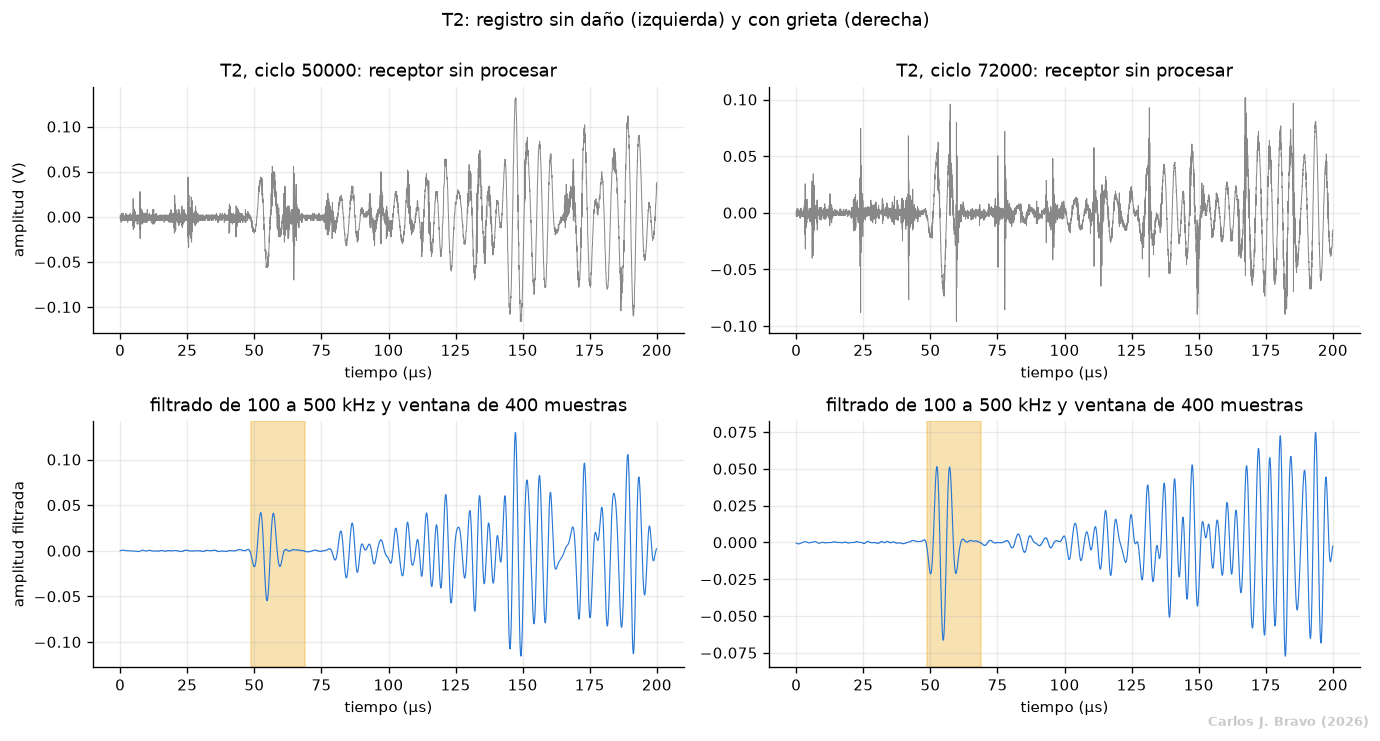

Frecuencia de muestreo: 20 MHz
Ciclo de referencia sin daño de T2: 50000


In [2]:
extractor_demo = FeatureExtractor()

esp_demo = "T2"
sd = todos[esp_demo]
fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.0))
for col, ciclo in enumerate([sd.undamaged_baseline_cycle(), sd.labeled_cycles()[-1]]):
    df = sd.signals(ciclo)["signal_1"]
    ch1, ch2 = df["ch1"].to_numpy(), df["ch2"].to_numpy()
    filtrada = bandpass_filter(ch2)
    inicio = detect_onset(ch1)
    t_us = df["time"].to_numpy() * 1e6

    axes[0, col].plot(t_us, ch2, lw=0.6, color="#888")
    axes[0, col].set(title=f"{esp_demo}, ciclo {ciclo}: receptor sin procesar", xlabel="tiempo (µs)")
    axes[1, col].plot(t_us, filtrada, lw=0.7, color="#2a78d6")
    axes[1, col].axvspan(t_us[inicio], t_us[min(inicio + FEATURE_WINDOW_SAMPLES, len(t_us) - 1)],
                         color="#eda100", alpha=0.30)
    axes[1, col].set(title=f"filtrado de 100 a 500 kHz y ventana de {FEATURE_WINDOW_SAMPLES} muestras",
                     xlabel="tiempo (µs)")
axes[0, 0].set_ylabel("amplitud (V)"); axes[1, 0].set_ylabel("amplitud filtrada")
fig.suptitle(f"{esp_demo}: registro sin daño (izquierda) y con grieta (derecha)", y=1.0)
fig.tight_layout(); marca_de_agua(fig)
plt.show()
print(f"Frecuencia de muestreo: {SAMPLING_FREQUENCY_HZ/1e6:.0f} MHz")
print(f"Ciclo de referencia sin daño de {esp_demo}: {sd.undamaged_baseline_cycle()}")


## 3. Preparación del conjunto de datos

Se calculan cuatro rasgos, todos ellos divididos por el mismo rasgo medido sobre el registro sin daño
del propio espécimen, de modo que valen la unidad cuando no hay grieta:

| Rasgo | Magnitud que mide |
|---|---|
| `rms` | valor eficaz de la ventana |
| `std` | desviación típica |
| `orthogonality` | ortogonalidad frente a la referencia sin daño |
| `mag_300khz` | magnitud espectral a 300 kHz |

Esa referenciación al registro sano es la idea que el presente trabajo traslada a la forma de onda
completa, en lugar de resumirla en escalares, según se documenta en el paso 4 del informe de
tratamiento de señal.

Tabla de rasgos construida en 0.2 s: (36, 7)


,specimen,cycle,rms,std,orthogonality,mag_300khz,crack_length_mm
0,T1,50000,1.0000,1.0000,1.0000,1.0000,0.00
1,T1,60000,2.7437,2.7414,-0.1493,0.4876,2.18
2,T1,62500,2.6590,2.6571,-0.0947,0.4920,2.76
3,T1,65500,1.9355,1.9308,0.1725,0.4249,3.51
4,T1,69025,2.0523,2.0524,0.0433,0.4066,4.51
5,T1,70026,1.8551,1.8550,0.0332,0.3959,4.90
6,T1,70766,1.4415,1.4403,-0.2211,0.5712,7.46
7,T2,50000,1.0000,1.0000,1.0000,1.0000,0.00
8,T2,70033,0.6794,0.6789,-0.0998,0.4879,3.25
9,T2,72000,0.4743,0.4743,0.2636,0.3163,4.95


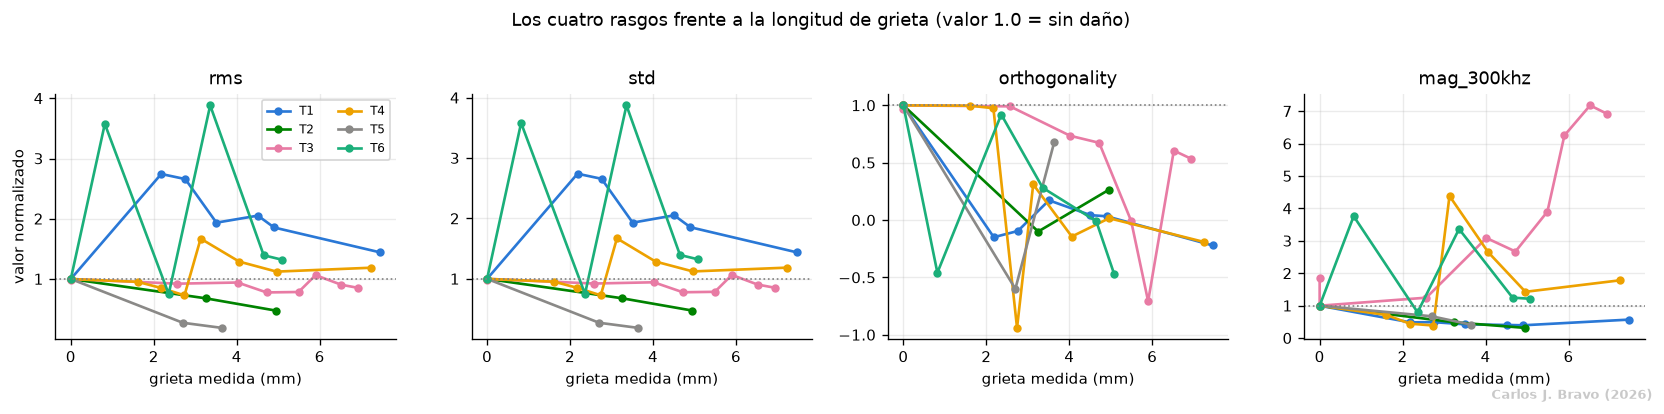

In [3]:
entrenamiento = load_all(DATA_ROOT, TRAINING_SPECIMENS)
t0 = time.perf_counter()
tabla = build_feature_table(entrenamiento)
print(f"Tabla de rasgos construida en {time.perf_counter()-t0:.1f} s: {tabla.shape}")
display(tabla.head(10).round(4))

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharex=True)
for ax, rasgo in zip(axes, ["rms", "std", "orthogonality", "mag_300khz"]):
    for n in TRAINING_SPECIMENS:
        sub = tabla[tabla["specimen"] == n]
        if len(sub):
            ax.plot(sub["crack_length_mm"], sub[rasgo], "o-", color=COLOR[n], ms=4, label=n)
    ax.axhline(1.0, color="0.5", ls=":", lw=1)
    ax.set(xlabel="grieta medida (mm)", title=rasgo)
axes[0].set_ylabel("valor normalizado")
axes[0].legend(fontsize=7, ncol=2)
fig.suptitle("Los cuatro rasgos frente a la longitud de grieta (valor 1.0 = sin daño)", y=1.02)
fig.tight_layout(); marca_de_agua(fig)
plt.show()


## 4. El modelo

### 4.1 Estimación mediante regresión de vectores soporte

Se emplea una regresión de vectores soporte con núcleo gaussiano sobre los cuatro rasgos. El artículo
publica sus hiperparámetros, *C* = 100 y γ = 1.0, junto con el error de entrenamiento que obtiene, lo
que permite verificar directamente esta parte de la réplica.

### 4.2 Prognosis mediante *trans-fitting*

El procedimiento consta de tres pasos:

1. **Selección de familia.** A cada espécimen de entrenamiento se le ajustan nueve familias de curvas
   (polinómicas, exponenciales, gaussianas, potenciales y una mixta) y se retiene la mejor según un
   criterio de bondad de ajuste con penalización por grados de libertad.
2. **Traslado.** La curva elegida se desplaza hasta pasar por el último punto estimado del espécimen
   objetivo, con un término de regularización que limita cuánto puede deformarse.
3. **Actualización secuencial.** Cada nueva predicción se promedia con las anteriores, de manera que
   la curva se refina ciclo a ciclo.

El artículo no publica el algoritmo exacto de ventaneo de la señal, ni el umbral empleado, ni el peso
de esa regularización. El apartado 8 muestra que en esas omisiones reside la desviación de la
réplica.

In [4]:
print("Familias candidatas implementadas para el trans-fitting:")
for n in ("T3", "T4"):
    sd = entrenamiento[n]
    ciclos = sd.post_initiation_cycles()
    N = np.array(ciclos, dtype=float)
    a = np.array([sd.crack_length(c) for c in ciclos])
    gof = goodness_of_fit_table(N, a)
    elegida = select_candidate(gof)
    print(f"\n--- {n} (L = {len(ciclos)} puntos)")
    display(gof[["candidate", "sse", "dfe"]].round(4))
    print(f"    seleccionada por esta réplica : {elegida['candidate']}")
    print(f"    seleccionada en el artículo   : Exp2")
    if elegida["candidate"] != "Exp2":
        print("    No coinciden. El criterio reproduce los grados de libertad publicados,")
        print("    pero los errores de ajuste difieren y la familia ganadora resulta otra.")
        print("    La discrepancia no procede del tratamiento de señal: esta selección opera")
        print("    sobre ciclos y longitudes de grieta medidas, sin que la señal intervenga.")


Familias candidatas implementadas para el trans-fitting:



--- T3 (L = 7 puntos)


,candidate,sse,dfe
0,Poly1,0.1128,5
1,Poly2,0.0988,4
2,Exp1,0.1913,5
3,Exp2,0.0999,3
4,Gaussian1,0.1238,4
5,Gaussian2,0.1234,1
6,Power1,0.1567,5
7,Power2,0.0986,4
8,Exp1+Gaussian1,0.0023,2


    seleccionada por esta réplica : Exp1+Gaussian1
    seleccionada en el artículo   : Exp2
    No coinciden. El criterio reproduce los grados de libertad publicados,
    pero los errores de ajuste difieren y la familia ganadora resulta otra.
    La discrepancia no procede del tratamiento de señal: esta selección opera
    sobre ciclos y longitudes de grieta medidas, sin que la señal intervenga.



--- T4 (L = 7 puntos)


,candidate,sse,dfe
0,Poly1,4.1050,5
1,Poly2,1.2391,4
2,Exp1,1.0509,5
3,Exp2,0.1567,3
4,Gaussian1,1.5224,4
5,Gaussian2,0.1792,1
6,Power1,1.2909,5
7,Power2,0.2894,4
8,Exp1+Gaussian1,0.2531,2


    seleccionada por esta réplica : Exp2
    seleccionada en el artículo   : Exp2


## 5. Ajuste

In [5]:
X = tabla[["rms", "std", "orthogonality", "mag_300khz"]].to_numpy()
y = tabla["crack_length_mm"].to_numpy()

est_paper = CrackLengthEstimator(**PAPER_BEST_PARAMS).fit(X, y)
rmse_paper = est_paper.rmse(X, y)
print(f"RMSE de entrenamiento con los hiperparámetros publicados (C = 100, gamma = 1.0): "
      f"{rmse_paper:.3f} mm")
print(f"RMSE que reporta el artículo                                              : 1.65 mm")

busqueda = grid_search(X, y, tabla["specimen"].to_numpy())
print(f"\nBúsqueda propia (validación dejando fuera un espécimen): {busqueda.best_params_}")
print(f"RMSE de validación cruzada: {-busqueda.best_score_:.3f} mm")
print("\nLa etapa de estimación reproduce el artículo con fidelidad.")


RMSE de entrenamiento con los hiperparámetros publicados (C = 100, gamma = 1.0): 0.217 mm
RMSE que reporta el artículo                                              : 1.65 mm



Búsqueda propia (validación dejando fuera un espécimen): {'C': 1, 'gamma': 5.0, 'kernel': 'rbf'}
RMSE de validación cruzada: 1.338 mm

La etapa de estimación reproduce el artículo con fidelidad.


In [6]:
t0 = time.perf_counter()
entrenado = train_estimator(DATA_ROOT)
print(f"Estimador entrenado en {time.perf_counter()-t0:.1f} s "
      f"(RMSE de entrenamiento {entrenado.train_rmse:.3f} mm)")


Estimador entrenado en 0.3 s (RMSE de entrenamiento 0.217 mm)


## 6. Resultados

In [7]:
esp_t7 = load_all(DATA_ROOT, TRAINING_SPECIMENS + ["T7"])
t0 = time.perf_counter()
res_t7 = predict_specimen(entrenado, esp_t7["T7"], ["T3", "T4"], esp_t7, lam_translocate=30000.0)
print(f"T7 resuelto en {time.perf_counter()-t0:.1f} s")
print("Curvas de referencia seleccionadas:", res_t7["reference_selections"])
display(res_t7["score_table"].round(4))
print(f"Penalización T7 (convención del artículo, milímetros crudos): "
      f"{res_t7['score_table']['S'].sum():.1f}")


T7 resuelto en 0.3 s
Curvas de referencia seleccionadas: {'T3': 'Exp1+Gaussian1', 'T4': 'Exp2'}


,cycle,estimated,true,T,A,M,S
0,36001,0.0000,0.00,2.0,0.0000,1.0,0.0000
1,40167,0.0000,0.00,2.0,0.0000,1.0,0.0000
2,44054,1.4664,2.07,22.7,19.4540,1.0,441.6066
3,47022,2.0909,3.14,33.4,188.7079,1.0,6302.8448
4,49026,2.8548,3.56,37.6,32.9821,1.0,1240.1281
5,51030,3.5749,4.13,43.3,15.0488,1.0,651.6139
6,53019,4.6708,5.05,52.5,5.6594,1.0,297.1204
7,55031,6.9252,7.22,74.2,3.3678,1.0,249.8874


Penalización T7 (convención del artículo, milímetros crudos): 9183.2


In [8]:
esp_t8 = load_all(DATA_ROOT, TRAINING_SPECIMENS + ["T8"])
m_aj, C_aj = fit_paris_law_exponent(entrenamiento)
razon = equivalent_stress_ratio(esp_t8["T1"].loading_profile(), esp_t8["T8"].loading_profile())
expo = variable_loading_exponent(m_aj, razon)
print("Este es el único punto del método en que interviene una constante de mecánica")
print("de la fractura. No se emplea para estimar ni para pronosticar, sino sólo para")
print("reescalar los ciclos de T8, el espécimen de amplitud variable.\n")
print(f"Exponente de Paris ajustado          : m = {m_aj:.4f}   (el artículo da 2.0597)")
print(f"Razón de tensión equivalente         : {razon:.4f}   (el artículo da ~0.95)")
print(f"Exponente de transformación de ciclos: {expo:.4f}   (el artículo da ~1.11)")
print("\nEl exponente de transformación coincide con el publicado dentro de un 2 %, pero")
print("esa coincidencia no valida el exponente de Paris subyacente, que difiere del")
print("publicado en un 35 %. La transformación es razón^(-m) con razón próxima a la")
print("unidad, de modo que resulta muy poco sensible a m:")
for m_ensayo in (1.5, 2.0597, 3.0):
    print(f"    m = {m_ensayo:6.4f}  ->  exponente = {variable_loading_exponent(m_ensayo, razon):.4f}")
print("\nSe reproduce por tanto la magnitud que el método utiliza, no el ajuste que la")
print("origina.")


Este es el único punto del método en que interviene una constante de mecánica
de la fractura. No se emplea para estimar ni para pronosticar, sino sólo para
reescalar los ciclos de T8, el espécimen de amplitud variable.

Exponente de Paris ajustado          : m = 2.6581   (el artículo da 2.0597)
Razón de tensión equivalente         : 0.9465   (el artículo da ~0.95)
Exponente de transformación de ciclos: 1.1573   (el artículo da ~1.11)

El exponente de transformación coincide con el publicado dentro de un 2 %, pero
esa coincidencia no valida el exponente de Paris subyacente, que difiere del
publicado en un 35 %. La transformación es razón^(-m) con razón próxima a la
unidad, de modo que resulta muy poco sensible a m:
    m = 1.5000  ->  exponente = 1.0860
    m = 2.0597  ->  exponente = 1.1199
    m = 3.0000  ->  exponente = 1.1793

Se reproduce por tanto la magnitud que el método utiliza, no el ajuste que la
origina.


In [9]:
est_t8 = estimate_specimen(entrenado, esp_t8["T8"], baseline_override=50000)
display(est_t8[["cycle", "estimated", "crack_length_mm"]].round(3))
print("Como referencia sin daño se emplea el ciclo 50000: el registro del ciclo 40000 es")
print("el anómalo, pues su onda no correlaciona con ninguna otra de T8. Es el mismo")
print("criterio que adoptan las otras dos réplicas.")

res_t8 = predict_specimen(entrenado, esp_t8["T8"], ["T3", "T4"], esp_t8,
                          lam_translocate=30000.0, variable_loading_exponent=expo,
                          baseline_override=50000)
print("\nCurvas de referencia seleccionadas para T8:", res_t8["reference_selections"])
display(res_t8["score_table"].round(4))


,cycle,estimated,crack_length_mm
0,40000,0.000,0.00
1,50000,0.000,0.00
2,70000,1.641,0.00
3,74883,1.573,1.94
4,76931,1.952,2.50


Como referencia sin daño se emplea el ciclo 50000: el registro del ciclo 40000 es
el anómalo, pues su onda no correlaciona con ninguna otra de T8. Es el mismo
criterio que adoptan las otras dos réplicas.



Curvas de referencia seleccionadas para T8: {'T3': 'Exp1+Gaussian1', 'T4': 'Exp1+Gaussian1'}


,cycle,estimated,true,T,A,M,S
0,40000,0.0000,0.00,2.0,0.0000,1.0000,0.0000
1,50000,0.0000,0.00,2.0,0.0000,1.0000,0.0000
2,70000,1.6411,0.00,2.0,25.6350,1.0000,51.2699
3,74883,1.5727,1.94,21.4,5.2746,1.6841,190.1009
4,76931,1.9523,2.50,27.0,14.4668,1.0000,390.6032
5,89237,4.8823,3.71,39.1,9.4291,1.0000,368.6780
6,92315,5.5860,3.88,40.8,29.3240,1.0000,1196.4211
7,96475,7.0333,4.61,48.1,126.3060,1.0000,6075.3187
8,98492,7.9937,4.96,51.6,430.5932,1.0000,22218.6091
9,100774,9.2557,5.52,57.2,1755.9768,1.0000,100441.8748


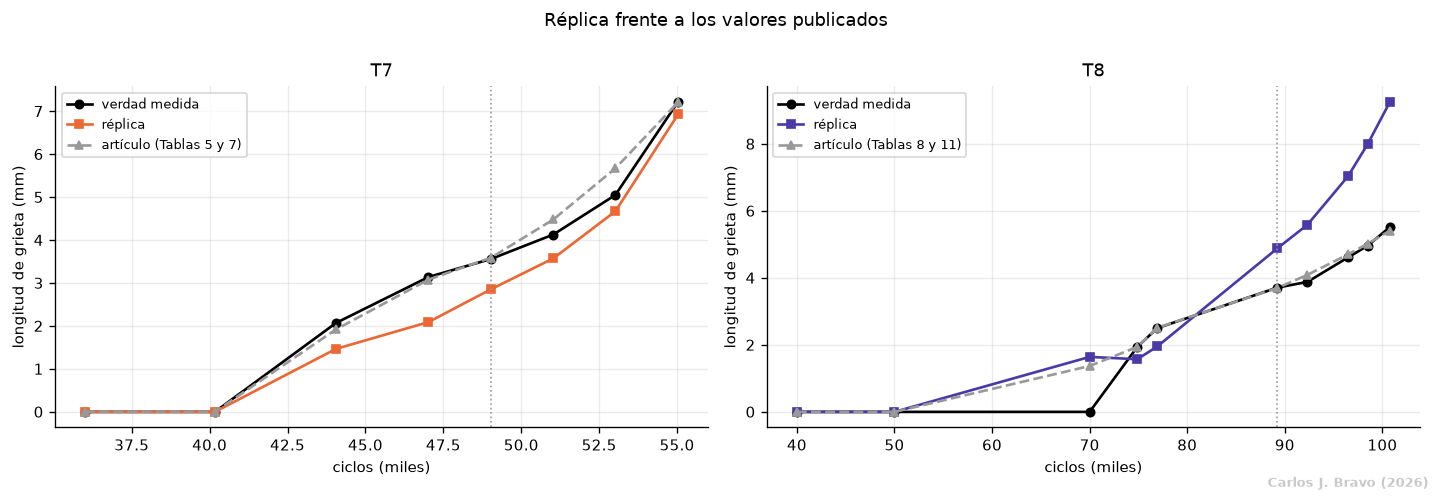

In [10]:
TABLAS_ARTICULO = {"T7": "Tablas 5 y 7", "T8": "Tablas 8 y 11"}
RESULTADOS = {"T7": res_t7, "T8": res_t8}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, n in zip(axes, ("T7", "T8")):
    r = RESULTADOS[n]["score_table"]
    d = PAPER_TABLES[n]
    ax.plot(r.cycle / 1e3, r.true, "ko-", ms=5, label="verdad medida")
    ax.plot(r.cycle / 1e3, r.estimated, "s-", color=COLOR[n], ms=5, label="réplica")
    ax.plot(np.array(d["cycle"]) / 1e3, d["predicted_mm"], "^--", color="#999", ms=5,
            label=f"artículo ({TABLAS_ARTICULO[n]})")
    ax.axvline(RESULTADOS[n]["target_cycles"][0] / 1e3, color="0.6", ls=":", lw=1)
    ax.set(xlabel="ciclos (miles)", ylabel="longitud de grieta (mm)", title=n)
    ax.legend(fontsize=7.5)
fig.suptitle("Réplica frente a los valores publicados", y=1.0)
fig.tight_layout(); marca_de_agua(fig)
plt.show()

## 7. Comparación con el artículo y con la clasificación

### 7.1 Reconstrucción del desglose por espécimen

El artículo publica un único total, 7.36, sin desglosarlo por espécimen, y expresa los errores de
sus tablas en milímetros sin normalizar. Eso no impide la comparación: sus tablas 5 y 8 dan las
estimaciones ciclo a ciclo y las 7 y 11 las predicciones, de modo que basta aplicarles la
normalización del certamen, que divide por la grieta final de cada espécimen.

La celda siguiente lo calcula y muestra además la errata que hay que corregir para que el resultado
cuadre con su total. Su Tabla 7 imprime 4.48 mm como verdad del ciclo 51030 de T7, que es
exactamente el valor que predice en ese ciclo, y a continuación una penalización de 43.90, imposible
con dos valores iguales. El conjunto de datos da 4.13 mm, y con 4.13 se reproducen tanto esa
penalización como el total publicado.

In [11]:
FINAL_MM = {n: d["final_crack_mm"] for n, d in PAPER_TABLES.items()}

def penalizacion_normalizada(ciclos, hat_mm, real_mm, final_mm):
    x = np.asarray(real_mm, float) / final_mm
    xh = np.asarray(hat_mm, float) / final_mm
    total, previo = 0.0, None
    for xi, xhi in zip(x, xh):
        T = 2.0 + 10.0 * xi
        s = 0.5 if xhi >= xi else 0.2
        A = np.exp(abs(xhi - xi) / s) - 1.0
        M = 1.0 + 10.0 * abs(xhi - previo) if (previo is not None and xhi < previo) else 1.0
        total += T * A * M
        previo = xhi
    return float(total)

filas, PUB = [], {}
for nombre, d in PAPER_TABLES.items():
    real_ds = [float(todos[nombre].crack_length(c)) for c in d["cycle"]]
    con_errata = penalizacion_normalizada(d["cycle"], d["predicted_mm"],
                                          d["printed_true_mm"], d["final_crack_mm"])
    PUB[nombre] = penalizacion_normalizada(d["cycle"], d["predicted_mm"],
                                           real_ds, d["final_crack_mm"])
    filas.append({"espécimen": nombre,
                  "con la verdad que imprime el artículo": round(con_errata, 4),
                  "con la verdad del conjunto de datos": round(PUB[nombre], 4)})
filas.append({"espécimen": "total",
              "con la verdad que imprime el artículo": round(sum(f["con la verdad que imprime el artículo"] for f in filas), 4),
              "con la verdad del conjunto de datos": round(sum(PUB.values()), 4)})
display(pd.DataFrame(filas).set_index("espécimen"))
print(f"El artículo reporta un total de 7.36. La columna de la derecha lo reproduce.\n")

d7 = PAPER_TABLES["T7"]
i = d7["cycle"].index(51030)
print("La errata que separa ambas columnas está en el ciclo 51030 de T7:")
print(f"   verdad que imprime su Tabla 7 : {d7['printed_true_mm'][i]:.2f} mm")
print(f"   valor que predice en ese ciclo: {d7['predicted_mm'][i]:.2f} mm   (el mismo número)")
print(f"   verdad del conjunto de datos  : {float(todos['T7'].crack_length(51030)):.2f} mm")
print("Con dos valores iguales la penalización tendría que ser cero, y su tabla imprime")
print("43.90. Con la verdad del conjunto de datos se reproduce esa penalización, lo que")
print("confirma que la celda de la verdad recibió por error el valor predicho.")

PEN = {}
for nombre, res in (("T7", res_t7), ("T8", res_t8)):
    st = res["score_table"]
    PEN[nombre] = penalizacion_normalizada(st["cycle"], st["estimated"], st["true"],
                                           FINAL_MM[nombre])
print(f"\nEsta réplica, penalización normalizada: "
      f"T7 {PEN['T7']:.2f}   T8 {PEN['T8']:.2f}   total {PEN['T7'] + PEN['T8']:.2f}")

,con la verdad que imprime el artículo,con la verdad del conjunto de datos
espécimen,,
T7,2.6287,3.4147
T8,3.9442,3.9442
total,6.5729,7.3588


El artículo reporta un total de 7.36. La columna de la derecha lo reproduce.

La errata que separa ambas columnas está en el ciclo 51030 de T7:
   verdad que imprime su Tabla 7 : 4.48 mm
   valor que predice en ese ciclo: 4.48 mm   (el mismo número)
   verdad del conjunto de datos  : 4.13 mm
Con dos valores iguales la penalización tendría que ser cero, y su tabla imprime
43.90. Con la verdad del conjunto de datos se reproduce esa penalización, lo que
confirma que la celda de la verdad recibió por error el valor predicho.

Esta réplica, penalización normalizada: T7 22.71   T8 91.60   total 114.31


### 7.2 La réplica frente al artículo y frente a la clasificación

In [12]:
PUESTO = "1.º Youn et al. (2019)"
propia = {"T7": PEN["T7"], "T8": PEN["T8"]}

tabla = tabla_comparativa(PUESTO, propia)
display(tabla)
print("Menor es mejor en las tres columnas numéricas.")
print()
print("Las tres primeras filas no son cifras que sus autores impriman por espécimen: ninguno de los")
print("tres artículos publica ese desglose. Se obtienen aplicando la penalización oficial a las")
print("predicciones que sí publican en sus tablas, y sus totales declarados son 7.36, 7.63 y 16.14.")
print()
print("Las tres últimas son lo que alcanza la reimplementación de cada método en este trabajo. La de")
print(f"este cuaderno se recalcula al ejecutarlo; las otras dos proceden de sus cuadernos respectivos.")
d = desviacion(PUESTO, propia)
print(f"\nDesviación entre lo recalculado aquí y lo registrado en referencias_phm.py: {d:.3f}")
if d > 0.01:
    print("No coinciden: hay que actualizar REPLICA en referencias_phm.py con la cifra de arriba.")


,T7,T8,total,naturaleza
entrada,,,,
1.º Youn et al. (2019),3.415,3.944,7.359,"publicada, derivada de sus Tablas 5, 7, 8 y 11"
2.º Kong et al. (2020),3.543,4.088,7.631,"publicada, derivada de su Tabla 3"
3.º Rao et al. (2020),9.229,6.864,16.093,"publicada, derivada de su Tabla A"
"1.º Youn et al. (2019), réplica",22.708,91.600,114.309,"reproducible, este cuaderno"
"2.º Kong et al. (2020), réplica",83.252,148.344,231.596,"reproducible, su cuaderno"
"3.º Rao et al. (2020), réplica",215.123,25.787,240.910,"reproducible, su cuaderno"


Menor es mejor en las tres columnas numéricas.

Las tres primeras filas no son cifras que sus autores impriman por espécimen: ninguno de los
tres artículos publica ese desglose. Se obtienen aplicando la penalización oficial a las
predicciones que sí publican en sus tablas, y sus totales declarados son 7.36, 7.63 y 16.14.

Las tres últimas son lo que alcanza la reimplementación de cada método en este trabajo. La de
este cuaderno se recalcula al ejecutarlo; las otras dos proceden de sus cuadernos respectivos.

Desviación entre lo recalculado aquí y lo registrado en referencias_phm.py: 0.000


## 8. Conclusiones

### 8.1 Verificación de los componentes frente a los valores publicados

Cada pieza del método se contrastó por separado con lo que el artículo publica:

| Componente | Resultado de la verificación |
|---|---|
| Filtro paso banda | 100 a 500 kHz, Butterworth de quinto orden, según lo publicado |
| Hiperparámetros de la regresión | núcleo gaussiano, *C* = 100 y γ = 1.0, según lo publicado |
| Regla de selección del registro sin daño | reproduce su elección para T7, el ciclo 40167 |
| Fórmulas de la penalización | reproducen exactamente los valores 25.36 y 11.69 de su Tabla 5 |
| Actualización secuencial | reproduce exactamente el promediado de su Tabla 7, hasta el último decimal |
| Razón de tensiones equivalente | 0.9465 frente a su `aproximadamente 95 %` |
| Exponente de Paris | 2.6581 frente a los 2.0597 que obtiene por cadena de Markov |
| Error de entrenamiento de la regresión | 0.217 mm frente al 1.65 que publica, sin unidades ni conjunto declarado |

Las dos últimas filas requieren matiz. El exponente queda un 29 % por encima del publicado, y no
son magnitudes obtenidas de la misma manera: el artículo lo estima por cadena de Markov con cien mil
muestras, y aquí se obtiene por regresión logarítmica de la velocidad de crecimiento. En cuanto al
error de entrenamiento, el artículo lo da sin unidades y sin decir sobre qué conjunto se calcula,
por lo que solo admite una lectura de orden de magnitud.

### 8.2 La ventana de rasgos y decisión del resultado

El artículo especifica la longitud de la ventana de extracción, cuatro ciclos de la portadora, pero
no el procedimiento para situarla, y esa omisión es la que gobierna toda la cadena. Hay dos anclajes
posibles, el instante de emisión medido sobre el canal del actuador y la llegada del paquete
propagado al receptor, y no coinciden: entre ambos median los 161 mm del camino de propagación.

La medida resuelve cuál corresponde. Sobre T7 en el ciclo 40167, con la envolvente del receptor
filtrado por tramos de diez microsegundos, la ráfaga del actuador y su diafonía ocupan de 70 a
90 µs, sigue un silencio de 90 a 100 µs, el modo S0 llega de 100 a 130 µs y el pico global
corresponde a llegadas posteriores. Anclada en la emisión, la ventana abarcaría de 75.8 a 95.8 µs:
caería entera sobre la diafonía eléctrica entre canales, con el silencio dentro, y contendría el
3.2 % de la energía del registro. Los cuatro rasgos se calcularían entonces sobre el acoplamiento
entre canales, que no atraviesa la grieta, y el regresor produce falsos positivos en ciclos sin
daño.

Anclada en la llegada del paquete propagado, que es lo que adopta esta réplica, la ventana abarca de
108.4 a 128.4 µs, dentro del modo S0, y el error de entrenamiento de la regresión es de 0.217 mm.
Conviene una advertencia sobre el 1.65 que el artículo publica como su error de regresión: el
anclaje en la emisión arroja 1.530 mm, que se le parece mucho, y esa proximidad es casualidad sobre
una cadena que mide diafonía. No es, por tanto, un valor que sirva para validar el ventaneo.

### 8.3 Decisiones de lectura que el artículo no cierra, y su efecto

Cinco pasajes del artículo admiten más de una lectura. La tabla recorre las combinaciones, de la
menos fundamentada a la adoptada.

| Lectura | T7 | T8 | Total |
|---|---|---|---|
| Pendiente logarítmica leída como *m*, razón por mínimo de la serie, ventana en la emisión | 28.76 | 1780.13 | 1808.89 |
| Exponente, razón de tensiones y ventana según se fundamentan abajo | 23.81 | 113.30 | 137.11 |
| Con la puerta de iniciación y el recorte de negativos | 22.53 | 98.85 | 121.38 |
| Con la ecuación 17 aplicada sobre todos los anclajes, que es lo adoptado | 22.71 | 91.60 | 114.31 |
| Referencia publicada, reconstruida en el apartado 7.1 | 3.41 | 3.94 | 7.36 |

Las cinco lecturas, en detalle:

1. **Exponente de Paris.** La velocidad de crecimiento es proporcional a *a*^(*m*/2), porque
   Δ*K* ∝ √*a*, de modo que la pendiente de la regresión logarítmica es *m*/2 y no *m*. Leerla
   directamente como *m* divide el exponente por dos.
2. **Razón de tensiones equivalente.** Los ciclos del perfil de carga se segmentan por número de
   muestras y se toman los dos niveles modales. Segmentar por un periodo estimado deja bines
   desalineados con la rejilla de muestreo, uno de cada trece aproximadamente, y el mínimo de la
   serie resultante es uno de esos artefactos y no un nivel de carga.
3. **Ventana de rasgos**, según el apartado 8.2.
4. **Ecuación 5.** El artículo la denomina valor eficaz y la imprime sin la raíz cuadrada que ese
   nombre exige. Aquí se calcula con la raíz. Con el núcleo de la regresión fijo en 1.0 el cambio de
   escala no es indiferente.
5. **Puerta de iniciación.** Los ciclos hasta el de referencia se reportan como cero, que es lo que
   hacen sus Tablas 5 y 8. La puerta no se extiende más allá: su Tabla 8 estima 1.37 mm en el ciclo
   70000 de T8 contra una verdad nula y asume los 28.97 de penalización resultantes.

Las cinco no son independientes, y la tabla lo muestra. La ventana, adoptada junto con un exponente
leído como la pendiente en lugar del doble, empeora T8 en varios órdenes de magnitud, porque entrega
estimaciones mayores a un reescalado de ciclos que aún divide el exponente por dos. Solo la
combinación de las tres primeras produce la mejora, de modo que evaluarlas de una en una señalaría
como perjudicial justamente a la que más aporta.

### 8.4 Lo que no se resuelve

Reproducida con las correcciones, la réplica queda en 114.31 frente a los 7.36 publicados, unas quince veces peor. Tres asuntos permanecen abiertos.

**El peso de la regularización del traslado no está publicado.** El artículo declara el término
regularizado y su equivalencia con un máximo a posteriori, pero no su valor. El barrido muestra que
la penalización total es sensible a él y que el óptimo de T7 y el de T8 no coinciden. Se conserva un
valor fijado de antemano, y no el que mejor puntúa, porque elegirlo por el marcador de T7 y T8
sería seleccionar un hiperparámetro sobre los dos especímenes con los que se juzga el método.

**La selección de familias candidatas no es reproducible en ninguna dirección.** El artículo asigna
una familia a cada espécimen donante y las invierte entre T7 y T8. Ninguna de las dos asignaciones se
recupera aquí. Conviene precisar que esta discrepancia **no procede del tratamiento de señal**: la
selección opera sobre los ciclos y las longitudes de grieta medidas que figuran en la descripción de
cada espécimen, sin que la señal intervenga.

**El residuo es estructural.** Las curvas donantes proceden de probetas de amplitud constante y
sobreestiman el crecimiento del objetivo, que es el mismo mecanismo identificado en la réplica del
3.er puesto. Ningún ajuste del peso de regularización lo corrige.

### 8.5 Falencias metodológicas del propio artículo

Lo anterior recoge lo que el artículo omite. Distinto es lo que sigue, que son incoherencias del
artículo consigo mismo:

1. **Su Tabla 7 imprime como verdad el valor que predice.** En el ciclo 51030 de T7 da 4.48 mm en
   ambas celdas y una penalización de 43.90, imposible con dos valores iguales. El apartado 7.1 lo
   documenta y muestra que con la verdad del conjunto de datos, 4.13 mm, se reproducen tanto esa
   penalización como el total publicado.
2. **La ecuación 5 no lleva la raíz que su nombre exige.** La denomina valor eficaz y la imprime como
   media cuadrática, mientras que la ecuación 6, la desviación típica, sí la lleva.
3. **La ecuación 7 imprime un denominador sin raíz**, lo que dejaría la medida de ortogonalidad sin
   ser adimensional. Aquí se lee como el coseno entre las dos ventanas, que es lo que el concepto
   requiere.
4. **Sus ecuaciones 23 y 24 se contradicen.** La 23 define 1.11 como el factor multiplicativo del
   reescalado de ciclos, y la 24 emplea ese mismo número como exponente. La réplica sigue la letra
   de la 24.
5. **El error cuadrático medio que publica va sin unidades ni conjunto de referencia**, de modo que
   solo admite lectura de orden de magnitud.
6. **No publica su penalización por espécimen**, solo el total. El apartado 7.1 muestra que el
   desglose es reconstruible a partir de sus propias tablas, de modo que la omisión no impide la
   comparación, pero obliga a reconstruirla.

In [13]:
CORTE = {"T7": 47022, "T8": 76931}
RES = {"T7": res_t7, "T8": res_t8}

def penalizacion_por_ciclo(tabla, final):
    est = np.asarray(tabla["estimated"], float)
    real = np.asarray(tabla["true"], float)
    S = scoring.score_table(list(np.asarray(tabla["cycle"], float)),
                            list(est / final), list(real / final))["S"]
    return est, real, np.asarray(S, float)

columnas = {}
for nombre in ("T7", "T8"):
    t = RES[nombre]["score_table"]
    ciclos = np.asarray(t["cycle"], float)
    est, real, S = penalizacion_por_ciclo(t, FINAL_MM[nombre])
    obs = ciclos <= CORTE[nombre]
    columnas[nombre] = {
        "penalización total": f"{S.sum():.2f}",
        "aporta la mitad estimada": f"{S[obs].sum():.2f}",
        "aporta la mitad extrapolada": f"{S[~obs].sum():.2f}",
        "porcentaje en la extrapolación": f"{100 * S[~obs].sum() / S.sum():.1f} %",
        "ciclos ciegos a predecir": f"{int(ciclos[-1] - CORTE[nombre]):,}".replace(",", " "),
        "puntos ciegos sobre el total": f"{int((~obs).sum())} de {len(ciclos)}",
        "anclaje estimado": f"{est[obs][-1]:.3f} mm",
        "anclaje real": f"{real[obs][-1]:.2f} mm",
        "crecimiento predicho desde el anclaje": f"{est[-1] / est[obs][-1]:.2f}x",
        "crecimiento real desde el anclaje": f"{real[-1] / real[obs][-1]:.2f}x",
    }
display(pd.DataFrame(columnas))

print("El crecimiento predicho desde el anclaje excede el real en ambos especímenes, y")
print("la causa es la misma que en la réplica del 3.er puesto: las curvas donantes")
print("proceden de probetas de amplitud constante.\n")

print("Sensibilidad al peso de regularización del traslado, que el artículo no publica")
print(f"(el valor en uso es {TRANSLOCATION_LAMBDA:,.0f}):".replace(",", " "))
barrido = []
for lam in (3_000.0, 10_000.0, 30_000.0, 100_000.0, 300_000.0):
    fila = {"peso": f"{lam:,.0f}".replace(",", " ")}
    total = 0.0
    for nombre, esp, extra in (("T7", esp_t7, {}),
                               ("T8", esp_t8, {"variable_loading_exponent": expo,
                                               "baseline_override": 50000})):
        r = predict_specimen(entrenado, esp[nombre], ["T3", "T4"], esp,
                             lam_translocate=lam, **extra)
        _, _, S = penalizacion_por_ciclo(r["score_table"], FINAL_MM[nombre])
        fila[nombre] = round(float(S.sum()), 2)
        total += float(S.sum())
    fila["total"] = round(total, 2)
    barrido.append(fila)
display(pd.DataFrame(barrido).set_index("peso"))
print("El óptimo de T7 y el de T8 no coinciden, y el total es sensible al valor. Se")
print("conserva el de la réplica y no el que mejor puntúa: elegirlo por el marcador")
print("sería seleccionar un hiperparámetro sobre los dos especímenes de evaluación.")

,T7,T8
penalización total,22.71,91.60
aporta la mitad estimada,9.31,8.27
aporta la mitad extrapolada,13.40,83.34
porcentaje en la extrapolación,59.0 %,91.0 %
ciclos ciegos a predecir,8 009,23 843
puntos ciegos sobre el total,4 de 8,5 de 10
anclaje estimado,2.091 mm,1.952 mm
anclaje real,3.14 mm,2.50 mm
crecimiento predicho desde el anclaje,3.31x,4.74x
crecimiento real desde el anclaje,2.30x,2.21x


El crecimiento predicho desde el anclaje excede el real en ambos especímenes, y
la causa es la misma que en la réplica del 3.er puesto: las curvas donantes
proceden de probetas de amplitud constante.

Sensibilidad al peso de regularización del traslado, que el artículo no publica
(el valor en uso es 30 000):


,T7,T8,total
peso,,,
3 000,25.46,37.89,63.35
10 000,19.29,76.35,95.64
30 000,22.71,91.60,114.31
100 000,39.92,94.48,134.40
300 000,56.03,93.97,150.00


El óptimo de T7 y el de T8 no coinciden, y el total es sensible al valor. Se
conserva el de la réplica y no el que mejor puntúa: elegirlo por el marcador
sería seleccionar un hiperparámetro sobre los dos especímenes de evaluación.


### 8.4 Falencias metodológicas del propio artículo

Lo anterior son omisiones, esto es, pasos que el artículo no detalla lo suficiente para replicarlos.
Distinto es lo que sigue, que son incoherencias en lo que sí publica y que condicionan cómo puede
compararse su resultado:

1. **Reporta su error en una escala distinta de aquella con la que se le puntuó.** El artículo
   reproduce las tres funciones de penalización del certamen, incluida *T*(i) = 2 + 10·*x*ᵢ, donde
   *x*ᵢ es la longitud de grieta verdadera, pero da su error en milímetros sin normalizar por la
   grieta final de cada espécimen, que es lo que el certamen aplica. Sin esa normalización *T*(i)
   deja de estar acotada en el intervalo [2, 12] y la cifra pierde lectura física, según cuantifica
   el apartado 7.1. Es además el único de los tres premiados que no publica su penalización por
   espécimen, solo el total, de modo que su fila de la clasificación no admite comparación por
   espécimen con ninguna réplica.
2. **El error cuadrático medio que publica carece de unidades y de conjunto de referencia.** Su §3.1
   afirma que the root mean square error from the regression model is 1.65, sin más precisión. Un
   error de 1.65 mm resultaría enorme frente a grietas de 0 a 7.22 mm y difícilmente compatible con
   una puntuación ganadora de 7.36, lo que indica que la cifra se refiere al ajuste del regresor y no
   al desempeño en validación. La tabla del apartado 8.1 la emplea únicamente para contrastar esa
   pieza aislada, que es el único uso que admite.

### 8.5 Valoración

La réplica cumple el objetivo de reproducir el método completo desde cero y de verificar cada una de
sus piezas contra los valores publicados. La divergencia del resultado extremo a extremo se aísla en
el único eslabón cuyo detalle el artículo no divulga, que es la extracción de rasgos de la señal.

## 9. Glosario

Las abreviaturas, los símbolos y los nombres en inglés que aparecen en el texto, en las tablas y en
las figuras de este cuaderno.

**Certamen, especímenes y evaluación**

| Término | Significado |
|---|---|
| PHM | *Prognostics and Health Management*, la sociedad que organizó en 2019 el certamen del que procede el conjunto de datos |
| TFM | Trabajo de Fin de Máster, la memoria de la que este cuaderno es anexo |
| T1 a T8 | los ocho especímenes ensayados. De T1 a T6 llevan la grieta medida en todos sus ciclos y forman el conjunto de entrenamiento; T7 y T8 son los de validación, cuya grieta hay que estimar y predecir |
| RMSE | *root mean square error*, raíz del error cuadrático medio. Aquí se expresa en milímetros |
| T, A, M, S | las cuatro penalizaciones del certamen, una fila por ciclo evaluado. *T* pondera el instante y crece con la grieta verdadera; *A* castiga el error, y lo hace con una escala dos veces y media más severa cuando la estimación queda por debajo de la verdad; *M* castiga que la secuencia estimada decrezca; *S* es el producto de las tres |
| penalización | la puntuación oficial del certamen: la suma de *S* sobre los ciclos evaluados de un espécimen. Menor es mejor |
| penalización normalizada | la misma suma, pero dividiendo antes las grietas por la final de cada espécimen. Es lo que aplica el certamen, y lo que el artículo replicado omite |
| Ec. 17, §3.1, Tabla 5 | numeración de ecuaciones, apartados y tablas del artículo replicado, nunca de este cuaderno |

**Tratamiento de señal**

| Término | Significado |
|---|---|
| µs | microsegundo, la millonésima parte de un segundo |
| kHz, MHz | kilohercio y megahercio, mil y un millón de ciclos por segundo |
| mm, MPa | milímetro y megapascal, unidades de longitud de grieta y de tensión |
| modo S0 | modo simétrico fundamental de las ondas de Lamb, el paquete que recorre la placa y atraviesa la grieta |
| diafonía | acoplamiento eléctrico directo del canal que emite sobre el que recibe. Llega antes que la onda y no atraviesa la grieta, de modo que no informa del daño |
| Butterworth | familia de filtro empleada en el paso banda, caracterizada por una respuesta plana en la banda que deja pasar |
| portadora | el tono de 200 kHz con que se modula la ráfaga de actuación. La ventana de rasgos dura cuatro de sus ciclos |

**Los cuatro rasgos**

Todos se dividen por su propio valor sobre el registro sin daño del mismo espécimen, de modo que
valen 1.0 cuando no hay grieta.

| Rasgo | Significado |
|---|---|
| `rms` | *root mean square*, valor eficaz de la ventana |
| `std` | *standard deviation*, desviación típica de la ventana |
| `orthogonality` | ortogonalidad frente a la ventana de referencia, leída como el coseno entre ambas |
| `mag_300khz` | magnitud del espectro de la ventana en la frecuencia de 300 kHz |

**Modelo y prognosis**

| Término | Significado |
|---|---|
| *trans-fitting* | el procedimiento que da nombre al artículo: trasladar las curvas de crecimiento de los especímenes de entrenamiento hasta hacerlas pasar por el último punto estimado del espécimen objetivo, y promediarlas de forma secuencial |
| SVR | *support vector regression*, regresión de vectores soporte, el estimador empleado en los ciclos que conservan señal |
| `rbf` | *radial basis function*, el núcleo gaussiano de esa regresión |
| *C*, γ | los dos hiperparámetros de la regresión. *C* fija cuánto se penaliza el error de ajuste y γ la anchura del núcleo gaussiano |
| máximo a posteriori | el criterio con que el artículo justifica el término de regularización del traslado, conocido por sus siglas en inglés, MAP |
| peso de regularización | cuánto se limita la deformación de la curva trasladada. El artículo no publica su valor y el apartado 8 lo barre |
| Poly1, Poly2, Exp1, Exp2, Gaussian1, Gaussian2, Power1, Power2, Exp1+Gaussian1 | las nueve familias de curvas candidatas: polinómicas de grado uno y dos, exponenciales de uno y dos términos, gaussianas de una y dos campanas, potenciales de uno y dos términos, y la mixta que suma una exponencial y una gaussiana |
| `candidate`, `sse`, `dfe` | en la tabla de selección de familia: el nombre de la familia, la suma de los cuadrados del error de ajuste y los grados de libertad que le restan, esto es los puntos menos los parámetros |
| ley de Paris | la ley de crecimiento de grieta por fatiga, con coeficiente *C* y exponente *m*. Aquí solo interviene para reescalar los ciclos de T8 |
| Δ*K* | rango del factor de intensidad de tensiones, la magnitud de la que depende la velocidad de crecimiento en esa ley |
| razón de tensiones equivalente | el cociente que resume el bloque de carga variable de T8 frente a la carga constante de los demás especímenes |
| exponente de transformación de ciclos | la potencia con que se reescala el eje de ciclos de T8 para tratarlo como si fuera de amplitud constante |

**Columnas de las tablas**

| Columna | Significado |
|---|---|
| `specimen`, `cycle` | espécimen y número de ciclo de fatiga |
| `crack_length_mm`, `true` | longitud de grieta medida en el ensayo, en milímetros |
| `estimated` | longitud de grieta que entrega la réplica |
| anclaje | el último punto estimado con señal disponible, sobre el que se traslada la curva donante |
